# Chain Rule

A guided notebook on the **Chain Rule** for derivatives.

This notebook explains:

- composite functions
- why the chain rule is needed
- the intuition behind $\Delta t \to \Delta h \to \Delta T$
- step-by-step derivation
- worked examples
- Python visualizations
- exercises

This notebook follows the uploaded guidelines template.


## 1. Introduction

Many functions are built by putting one function inside another.

For example:

$$
T = f(h(t))
$$

Here:

- $t$ changes first
- this changes $h$
- then the change in $h$ changes $T$

So the dependency chain is:

$$
\Delta t \to \Delta h \to \Delta T
$$

The **Chain Rule** tells us how to differentiate this kind of nested relationship.


## 2. Composite Functions

A composite function has the form:

$$
T(t)=f(h(t))
$$

The function $h(t)$ is the **inner function**.

The function $f(h)$ is the **outer function**.

Example:

$$
T(t)=\sin(t^2)
$$

Here:

$$
h(t)=t^2
$$

and

$$
f(h)=\sin h
$$


## 3. Chain Rule Formula

If

$$
T=f(h(t))
$$

then

$$
\frac{dT}{dt}
=
\frac{dT}{dh}
\cdot
\frac{dh}{dt}
$$

This is the chain rule.

In prime notation:

$$
T'(t)=f'(h(t))h'(t)
$$

Meaning:

> Differentiate the outside function, keep the inside unchanged, then multiply by the derivative of the inside.


## 4. Intuition from Small Changes

The image shows this idea:

$$
\Delta t \to \Delta h \to \Delta T
$$

A small change in $t$ produces a small change in $h$.

A small change in $h$ produces a small change in $T$.

So the total rate of change is:

$$
\frac{\Delta T}{\Delta t}
=
\frac{\Delta T}{\Delta h}
\cdot
\frac{\Delta h}{\Delta t}
$$

Taking the limit gives:

$$
\frac{dT}{dt}
=
\frac{dT}{dh}
\cdot
\frac{dh}{dt}
$$


## 5. Derivation

Suppose:

$$
T=f(h)
$$

and

$$
h=h(t)
$$

For small changes:

$$
\frac{\Delta T}{\Delta t}
=
\frac{\Delta T}{\Delta h}
\cdot
\frac{\Delta h}{\Delta t}
$$

Now let $\Delta t\to0$.

Then $\Delta h\to0$ as well.

So:

$$
\lim_{\Delta t\to0}\frac{\Delta T}{\Delta t}
=
\lim_{\Delta h\to0}\frac{\Delta T}{\Delta h}
\cdot
\lim_{\Delta t\to0}\frac{\Delta h}{\Delta t}
$$

Therefore:

$$
\frac{dT}{dt}
=
\frac{dT}{dh}
\cdot
\frac{dh}{dt}
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## 6. Worked Example 1

Differentiate:

$$
T(t)=\sin(t^2)
$$

Identify the inner and outer functions:

$$
h(t)=t^2
$$

$$
T=\sin h
$$

Differentiate the outer function:

$$
\frac{dT}{dh}=\cos h
$$

Differentiate the inner function:

$$
\frac{dh}{dt}=2t
$$

Apply the chain rule:

$$
\frac{dT}{dt}
=
\cos(h)\cdot 2t
$$

Replace $h$ with $t^2$:

$$
T'(t)=2t\cos(t^2)
$$


## 7. Worked Example 2

Differentiate:

$$
y=(3x^2+1)^5
$$

Inner function:

$$
u=3x^2+1
$$

Outer function:

$$
y=u^5
$$

Differentiate:

$$
\frac{dy}{du}=5u^4
$$

and

$$
\frac{du}{dx}=6x
$$

Apply the chain rule:

$$
\frac{dy}{dx}=5u^4\cdot6x
$$

Substitute back:

$$
\frac{dy}{dx}=30x(3x^2+1)^4
$$


## 8. Worked Example 3

Differentiate:

$$
y=e^{\cos x}
$$

Inner function:

$$
u=\cos x
$$

Outer function:

$$
y=e^u
$$

Differentiate:

$$
\frac{dy}{du}=e^u
$$

and

$$
\frac{du}{dx}=-\sin x
$$

Therefore:

$$
\frac{dy}{dx}=e^{\cos x}(-\sin x)
$$

So:

$$
\frac{dy}{dx}=-e^{\cos x}\sin x
$$


## 9. Visualizing the Chain

Let:

$$
h(t)=t^2
$$

and

$$
T=f(h)=\sin h
$$

Then:

$$
T(t)=\sin(t^2)
$$

We can visualize:
- the inner function $h(t)$
- the outer function $f(h)$
- the composite function $T(t)$


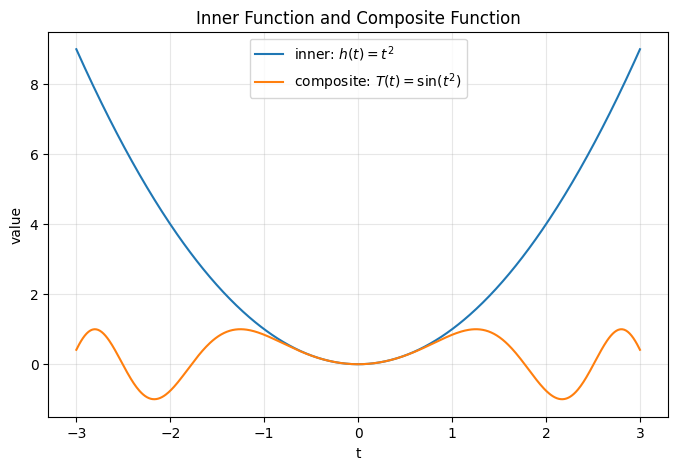

In [2]:
t = np.linspace(-3, 3, 600)
h = t**2
T = np.sin(h)

plt.figure(figsize=(8,5))
plt.plot(t, h, label=r"inner: $h(t)=t^2$")
plt.plot(t, T, label=r"composite: $T(t)=\sin(t^2)$")
plt.title("Inner Function and Composite Function")
plt.xlabel("t")
plt.ylabel("value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 10. Function and Derivative

For:

$$
T(t)=\sin(t^2)
$$

the derivative is:

$$
T'(t)=2t\cos(t^2)
$$


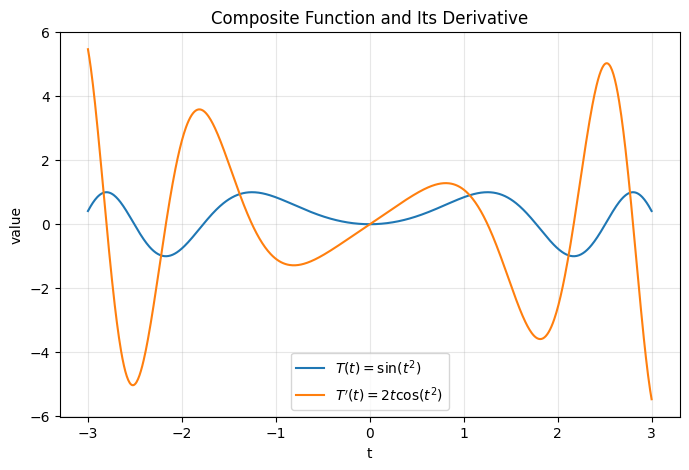

In [3]:
t = np.linspace(-3, 3, 800)
T = np.sin(t**2)
dT = 2*t*np.cos(t**2)

plt.figure(figsize=(8,5))
plt.plot(t, T, label=r"$T(t)=\sin(t^2)$")
plt.plot(t, dT, label=r"$T'(t)=2t\cos(t^2)$")
plt.title("Composite Function and Its Derivative")
plt.xlabel("t")
plt.ylabel("value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 11. Symbolic Checks with SymPy

In [4]:
x = sp.symbols('x')

examples = [
    sp.sin(x**2),
    (3*x**2 + 1)**5,
    sp.exp(sp.cos(x)),
    sp.log(x**2 + 1)
]

for expr in examples:
    print("f(x) =", expr)
    print("f'(x) =", sp.simplify(sp.diff(expr, x)))
    print("-" * 80)


f(x) = sin(x**2)
f'(x) = 2*x*cos(x**2)
--------------------------------------------------------------------------------
f(x) = (3*x**2 + 1)**5
f'(x) = 30*x*(3*x**2 + 1)**4
--------------------------------------------------------------------------------
f(x) = exp(cos(x))
f'(x) = -exp(cos(x))*sin(x)
--------------------------------------------------------------------------------
f(x) = log(x**2 + 1)
f'(x) = 2*x/(x**2 + 1)
--------------------------------------------------------------------------------


## 12. Numerical Check

We can compare the chain-rule derivative with a numerical derivative.


In [5]:
def numerical_derivative(func, x, h=1e-6):
    return (func(x + h) - func(x)) / h

def composite_function(t):
    return np.sin(t**2)

def chain_rule_derivative(t):
    return 2*t*np.cos(t**2)

t0 = 1.25

print("Numerical derivative:", numerical_derivative(composite_function, t0))
print("Chain rule result   :", chain_rule_derivative(t0))


Numerical derivative: 0.020737462413933372
Chain rule result   : 0.020740579059645943


## 13. Common Mistake

A common mistake is to differentiate only the outer function and forget the inner derivative.

Example:

$$
y=\sin(t^2)
$$

Wrong:

$$
y'=\cos(t^2)
$$

Correct:

$$
y'=\cos(t^2)\cdot 2t
$$

So:

$$
y'=2t\cos(t^2)
$$

The missing factor $2t$ comes from the derivative of the inner function $t^2$.


## 14. Chain Rule Pattern

For many functions, use this pattern:

$$
\frac{d}{dx}[\text{outside}(\text{inside})]
=
\text{outside}'(\text{inside})
\cdot
\text{inside}'
$$

Examples:

$$
\frac{d}{dx}\sin(g(x))=\cos(g(x))g'(x)
$$

$$
\frac{d}{dx}e^{g(x)}=e^{g(x)}g'(x)
$$

$$
\frac{d}{dx}\ln(g(x))=\frac{g'(x)}{g(x)}
$$

$$
\frac{d}{dx}[g(x)]^n=n[g(x)]^{n-1}g'(x)
$$


## 15. Exercises

### Basic

1. Differentiate:

$$
y=\sin(3x)
$$

2. Differentiate:

$$
y=(x^2+4)^3
$$

### Intermediate

3. Differentiate:

$$
y=e^{x^2}
$$

4. Differentiate:

$$
y=\ln(5x^2+1)
$$

### Advanced

5. Differentiate:

$$
y=\cos(\sin x)
$$

6. Explain in words why $\frac{dT}{dt}=\frac{dT}{dh}\frac{dh}{dt}$ makes sense.


## 16. Solutions / Checks

1.

$$
y'=3\cos(3x)
$$

2.

$$
y'=3(x^2+4)^2\cdot2x
=
6x(x^2+4)^2
$$

3.

$$
y'=e^{x^2}\cdot2x
=
2xe^{x^2}
$$

4.

$$
y'=\frac{10x}{5x^2+1}
$$

5.

$$
y'=-\sin(\sin x)\cdot\cos x
$$

6. A change in $t$ first changes $h$, and the change in $h$ changes $T$. The total rate is the rate from $h$ to $T$ multiplied by the rate from $t$ to $h$.


## 17. Conclusion

The chain rule is used for composite functions.

If:

$$
T=f(h(t))
$$

then:

$$
\frac{dT}{dt}
=
\frac{dT}{dh}
\cdot
\frac{dh}{dt}
$$

or equivalently:

$$
T'(t)=f'(h(t))h'(t)
$$

Key intuition:

$$
\Delta t \to \Delta h \to \Delta T
$$

A change in the input passes through the inner function first, then through the outer function.

The chain rule is one of the most important tools in calculus.
